In [124]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [125]:
point = np.linspace(1,10)
tendance = np.log(point)
periodicite = np.cos(point)
noise = np.random.rand(len(point))
ts = periodicite+tendance+noise

### Notre série temporelle

<Axes: >

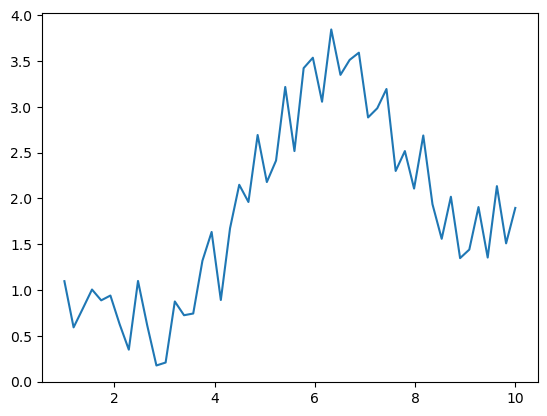

In [126]:
sns.lineplot(x=point, y=periodicite+tendance+noise)

# Extraction de la tendance

# Moyenne mobile

Avec pandas :

<Axes: ylabel='None'>

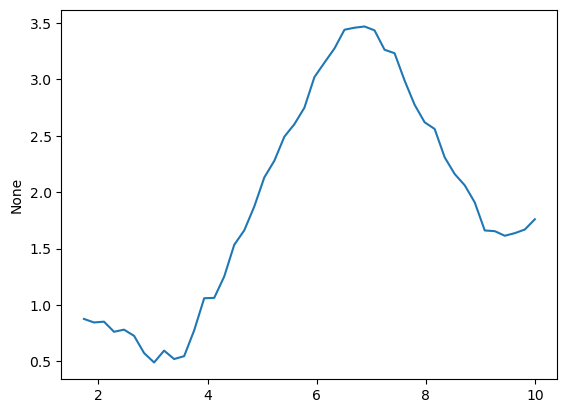

In [127]:
ts_pandas = pd.Series(ts)
average_mean = ts_pandas.rolling(window=5).mean()
sns.lineplot(x=point, y=average_mean)

Avec numpy :

<Axes: >

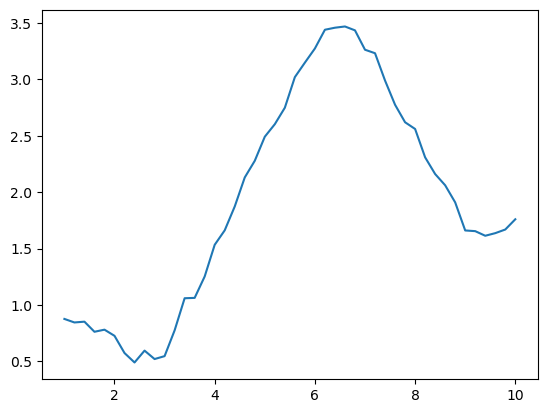

In [128]:
window_size = 5
np_average_mean = np.convolve(ts, np.ones(window_size)/window_size, mode='valid')
sns.lineplot(x=np.linspace(1,10,len(np_average_mean)), y=np_average_mean)

- Numpy permet de choisir le filtre exact appliqué (moyenne pondérée,...)
- Pandas a de nombreuses fonctions de fenêtre déjà implémentées
- Pandas maintient l'intervalle de départ
- Effet de bords

<Axes: ylabel='None'>

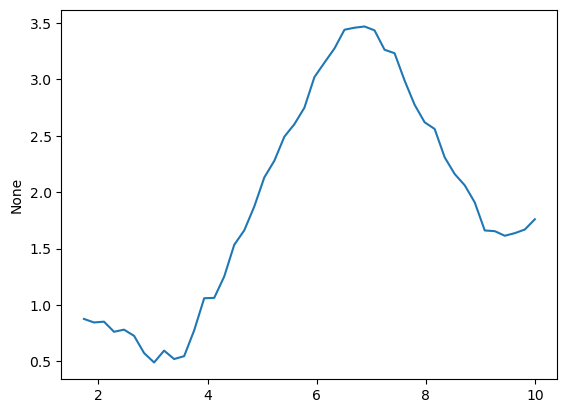

In [129]:
ts_pandas = pd.Series(ts)
average_mean = ts_pandas.rolling(window=5).mean()
sns.lineplot(x=point, y=average_mean)

Extraction du comportement 'stationnaire'

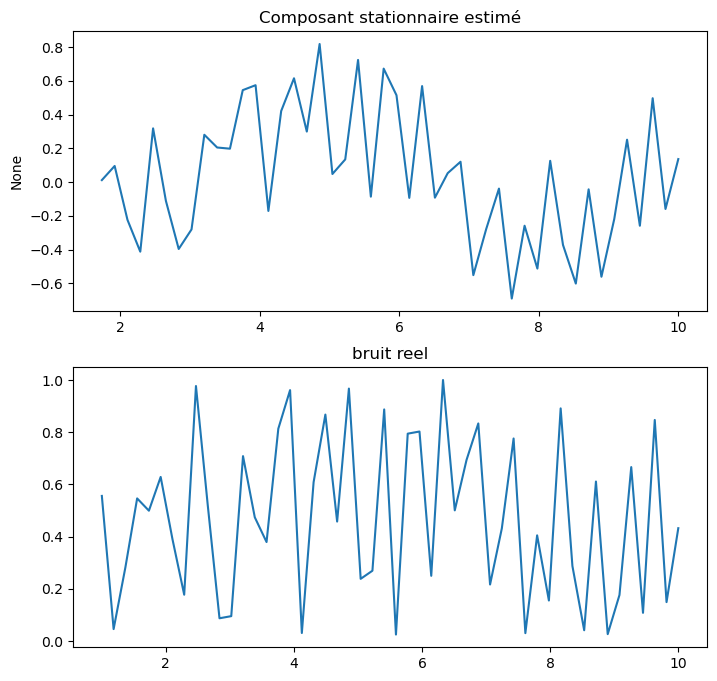

In [130]:
fig = plt.figure(figsize=(18,8))
plt.subplot(221)
sns.lineplot(x=point, y=ts-average_mean)
plt.title("Composant stationnaire estimé")
plt.subplot(223)
sns.lineplot(x=point, y=noise)
plt.title("bruit reel")
plt.show()

- mauvaise approximation car la moyenne mobile a pris en compte une partie de la saisonalité
- plus la fenetre est grande, plus le risque est important
- on n'a pas assez de valeurs pour arriver à isoler uniquement la tendance ou tendance et saisonalité, comme l'ordre de grandeur de la saisonalité est proche du nombre de point que l'on a

## Différentiation

<Axes: >

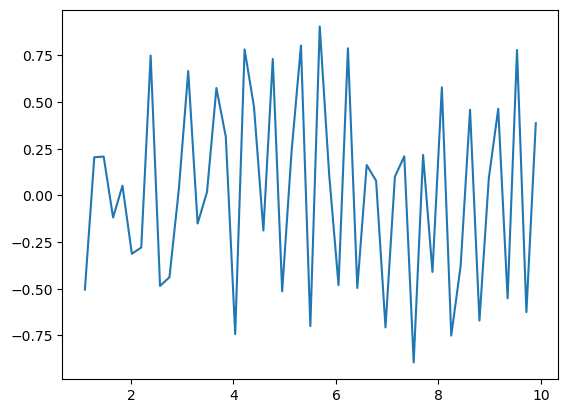

In [131]:
ts_dif = np.diff(ts)
point_dif = np.linspace(1.1,9.9,49)
sns.lineplot(x=point_dif, y=ts_dif)

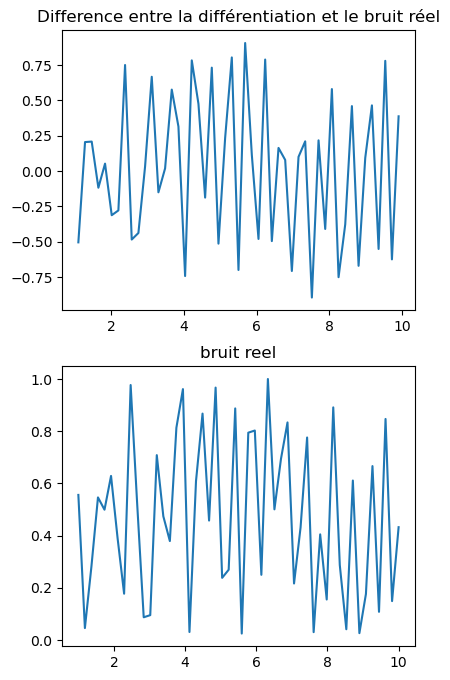

In [132]:
fig = plt.figure(figsize=(10,8))
plt.subplot(221)
sns.lineplot(x=point_dif, y=ts_dif)
plt.title("Difference entre la différentiation et le bruit réel")
plt.subplot(223)
sns.lineplot(x=point, y=noise)
plt.title("bruit reel")
plt.show()

- Proche mais pas parfait
- les pics marqués sont similaires, mais l'amplitude reste influencée par la tendance et saisonalité

- Avec pandas :

<Axes: ylabel='None'>

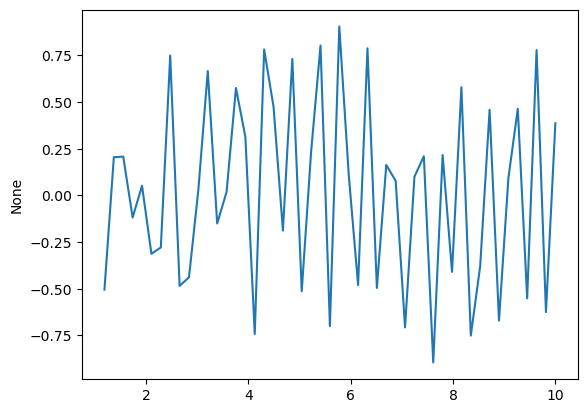

In [133]:
ts_pandas_dif = ts_pandas.diff()
sns.lineplot(x=point, y=ts_pandas_dif)

- différents lags

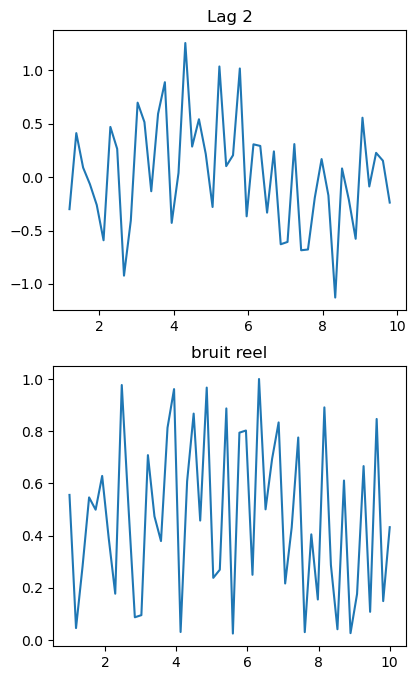

In [134]:
fig = plt.figure(figsize=(10,8))
plt.subplot(221)
sns.lineplot(x=np.linspace(1.2,9.8,48), y=ts[2:]-ts[:-2])
plt.title("Lag 2")
plt.subplot(223)
sns.lineplot(x=point, y=noise)
plt.title("bruit reel")
plt.show()

<Axes: >

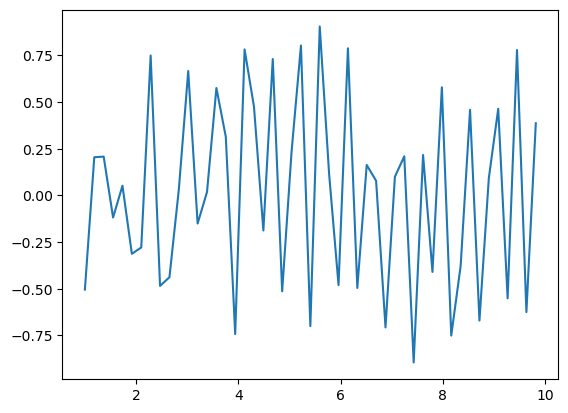

In [135]:
sns.lineplot(x=point[:-1], y=ts_dif)

# Outils automatiques

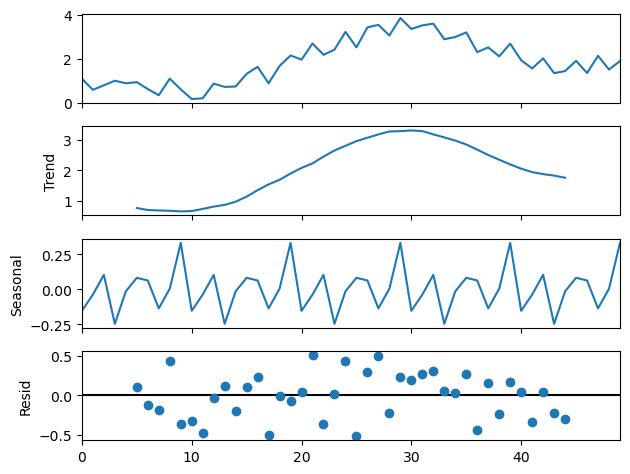

In [136]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompo = seasonal_decompose(ts_pandas, period=10)
_ = decompo.plot()

- ne pas croire tout ce que vous sort ce genre de méthodes

<Axes: ylabel='trend'>

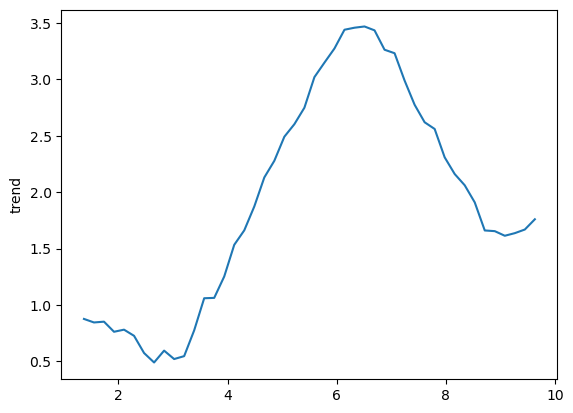

In [137]:
result = seasonal_decompose(ts_pandas, model='additive', period=5)
sns.lineplot(x=point, y=result.trend)

On retrouve la même tendance + saisonalité que notre moyenne mobile

# Auto-corrélation

- On a des graphes permettant de détecter l'autocorrélation visuellement (pour un lag donné):

Text(0.5, 1.0, 'Lag plot - Série temporelle avec lag=1')

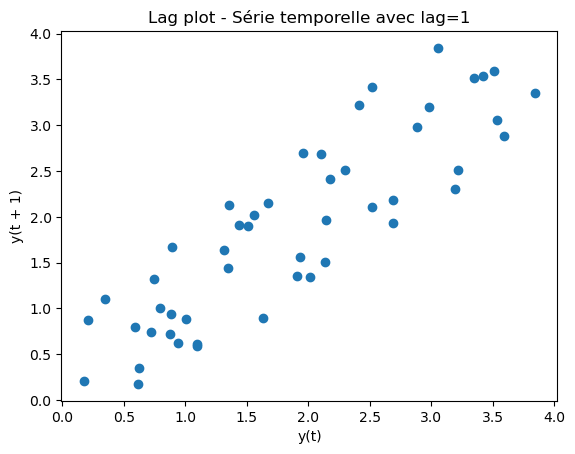

In [138]:
from pandas.plotting import lag_plot

lag_plot(ts_pandas, lag=1)
plt.title("Lag plot - Série temporelle avec lag=1")

- notre série n'est pas stationnaire car son autocorrélation n'est pas indépendante du temps

Text(0.5, 1.0, 'Lag plot - Bruit aléatoire avec lag=1')

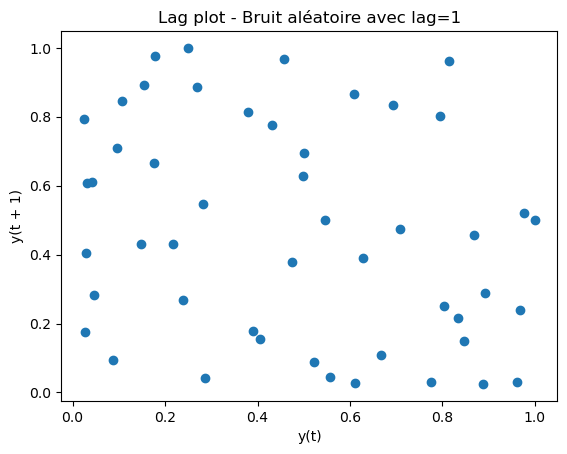

In [139]:
from pandas.plotting import lag_plot

lag_plot(pd.Series(noise), lag=1)
plt.title("Lag plot - Bruit aléatoire avec lag=1")

notre bruit aléatoire n'a pas l'air corrélé 
- On peut tester automatiquement différents lags

Text(0.5, 1.0, 'Autocorrelation plot - Tous les lags')

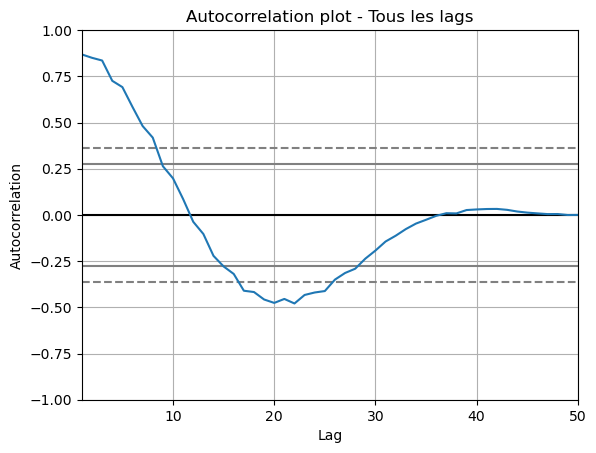

In [140]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(ts_pandas)
plt.title("Autocorrelation plot - Tous les lags")

- attention, ce n'est pas parce que l'on ne voit pas d'autocorrélation pour un certain lag qu'il n'y en a pas
- plus on va vers la droite, moins on a de donnée, donc plus le graphe est à prendre avec des pincettes
- les lignes fixes et pointillées sont les intervalles de confiances à 95% and 99% 

In [141]:
None

Text(0.5, 1.0, 'ACF plot - Autocorrelation Function')

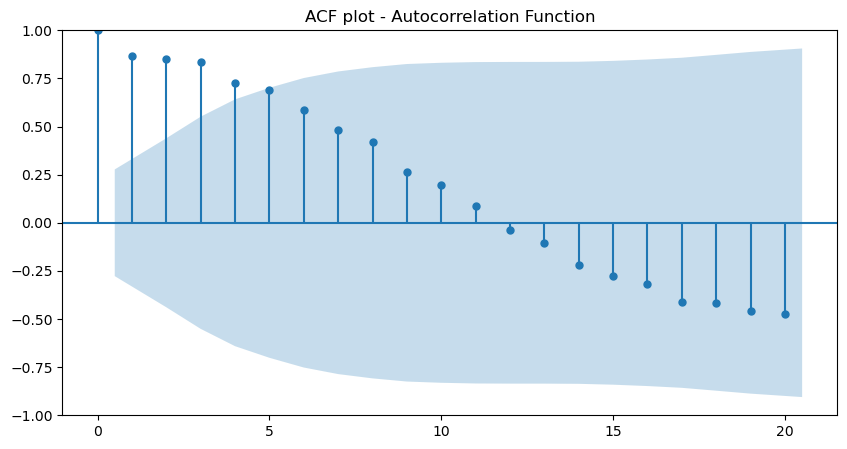

In [142]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ts_pandas.dropna(), lags=20, ax=ax)
plt.title("ACF plot - Autocorrelation Function")

- la zone en bleu indique la aussi là ou l'autocorrelation n'est pas jugée fiable
- elle a l'avantage de prendre en compte le nombre par rapport au lag, et augmente donc tres vite dans notre exemple

# Autoregression

### Prédiction du point suivant

In [143]:
from statsmodels.tsa.ar_model import AutoReg
X_train = ts[:-1]
model = AutoReg(X_train, lags=5)
model_fit = model.fit()

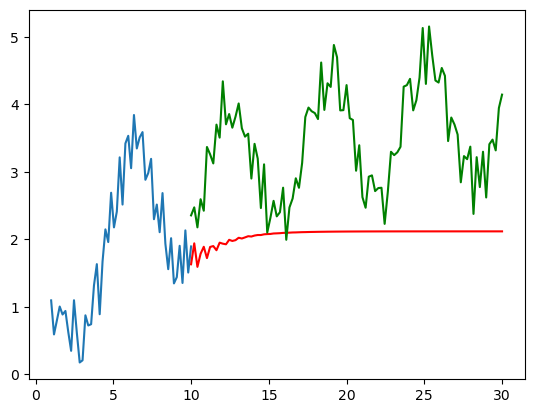

In [144]:
preds = model_fit.predict(start=len(X_train), end=len(X_train)+98,dynamic=False)

point_preds = np.linspace(10,30,num=99)
ts_true = np.log(point_preds) + np.cos(point_preds) +np.random.rand(len(point_preds))
plt.plot(point, ts)
plt.plot(point_preds, preds, color='red')
plt.plot(point_preds, ts_true, color='green')

- localement fiable, mais plus on s'eloigne moins on est précis comme les erreurs se cumulent
- limité par le nombre de points que l'on a

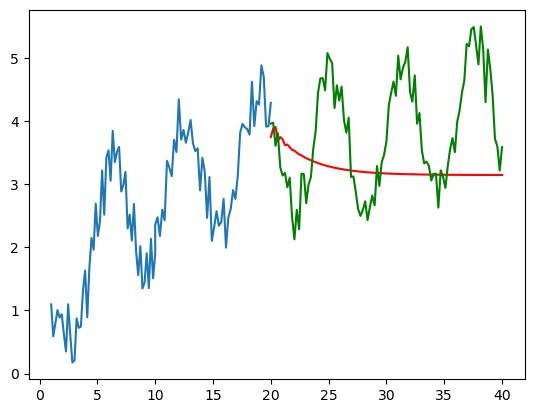

In [145]:
from statsmodels.tsa.ar_model import AutoReg
X_train = np.append(ts,ts_true[:50])
points_train = np.append(point,point_preds[:50])
model = AutoReg(X_train, lags=5)
model_fit = model.fit()
preds = model_fit.predict(start=len(X_train), end=len(X_train)+98,dynamic=False)
point_preds = np.linspace(20,40,num=99)
ts_true = np.log(point_preds) + np.cos(point_preds) +np.random.rand(len(point_preds))
plt.plot(points_train, X_train)
plt.plot(point_preds, preds, color='red')
plt.plot(point_preds, ts_true, color='green')

c:\Users\benoi\miniconda3\envs\ml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


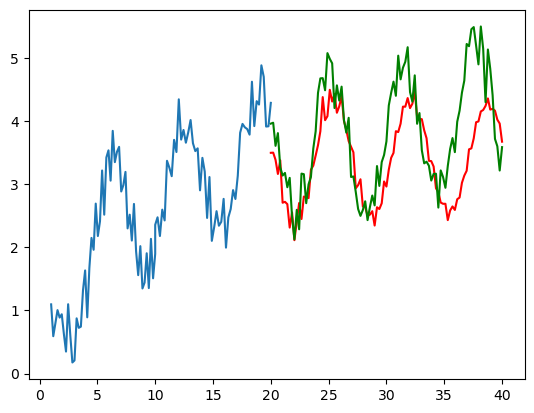

In [154]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(X_train, order=(30, 1, 2))
model_fit = model.fit()
preds = model_fit.predict(start=len(X_train), end=len(X_train)+98,dynamic=False)

plt.plot(points_train, X_train)
plt.plot(point_preds, preds, color='red')
plt.plot(point_preds, ts_true, color='green')

- augmenter le pas est vite couteux, comme ça augmente l'ordre du systeme d'equation à résoudre